引入套件

In [46]:
import streamlit as st
import pandas as pd
import os
import zipfile
import io
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from sklearn.model_selection import train_test_split
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
sns.set_theme(style="whitegrid")
%matplotlib inline
results_data = []



In [47]:
import pandas as pd
import os

# 1. 定義你的 Mac 桌面路徑
# 建議使用原始字串 r'' 避免路徑符號出問題
data_path = "../data/stroke.csv"

# 2. 檢查檔案是否存在並讀取
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    
    # --- 【自動標記核心】 ---
    # 取得最後一欄的名稱 (不論它叫 stroke 還是其他名字)
    target_col = df.columns[-1] 
    
    # 3. 數據預覽與診斷
    print(f"✅ 成功載入檔案：{os.path.basename(data_path)}")
    print(f"🎯 自動識別 Target 欄位: {target_col}")
    
    # 4. 檢查中風 (1) 與健康 (0) 的數量
    # 就算前幾列都是 0，這行會告訴你整份資料有多少個 1
    counts = df[target_col].value_counts()
    print(f"📊 類別分佈:\n{counts}")

    # 5. 清理：移除 id 欄位 (它對預測沒幫助)
    if 'id' in df.columns:
        df = df.drop(columns=['id'])
        print("🗑️ 已移除 id 欄位")
else:
    print("❌ 找不到檔案，請檢查資料夾名稱是否包含全形括號 (1)")


✅ 成功載入檔案：stroke.csv
🎯 自動識別 Target 欄位: stroke
📊 類別分佈:
stroke
0    4861
1     249
Name: count, dtype: int64
🗑️ 已移除 id 欄位


In [48]:
import os
import pandas as pd

# 1. 設定基礎路徑 (確保與你的資料夾層級一致)
data_dir = "../data" 
files = ["diabetes.csv", "heart.csv", "stroke.csv"] # 或是 "storke.csv"

# 2. 用來存放結果的字典
all_datasets = {}

# 3. 執行迴圈：讀取、自動抓取最後一欄作為 Target
for filename in files:
    full_path = os.path.join(data_dir, filename)
    
    if os.path.exists(full_path):
        # 讀取 CSV
        df = pd.read_csv(full_path)
        
        # --- 【核心邏輯】取得最後一欄並標記成 target ---
        target_name = df.columns[-1] 
        
        # 進行簡單的清理 (例如移除 ID，不分大小寫)
        id_cols = [c for c in df.columns if c.lower() == 'id']
        if id_cols:
            df = df.drop(columns=id_cols)
            # 重新取得最後一欄名稱，確保 target 還是最後一個
            target_name = df.columns[-1] 
            
        # --- 【診斷區】檢查標籤分佈 (回答你全 0 的疑惑) ---
        counts = df[target_name].value_counts()
        pos_cases = counts.get(1, 0) # 取得 1 (有病) 的數量，沒有則為 0
        
        # 存入字典
        dataset_key = filename.split('.')[0].capitalize()
        all_datasets[dataset_key] = (df, target_name)
        
        print(f"✅ {dataset_key:12} | Target: {target_name:15} | 案例數: {pos_cases}")
    else:
        print(f"❌ 找不到檔案: {filename}，請檢查路徑或拼字！")



✅ Diabetes     | Target: Outcome         | 案例數: 268
✅ Heart        | Target: target          | 案例數: 265
✅ Stroke       | Target: stroke          | 案例數: 249


In [49]:
import os
import pandas as pd
import numpy as np

# 1. 確保路徑與檔案清單正確
data_dir = "../data" 
files = ["diabetes.csv", "heart.csv", "stroke.csv"]

print("🔬 --- 開始逐一檢視檔案內容 (確保無重複) ---")

for filename in files:
    full_path = os.path.join(data_dir, filename)
    
    if os.path.exists(full_path):
        current_df = pd.read_csv(full_path)
        
        rows, cols = current_df.shape
        target_col = current_df.columns[-1]
        
        print(f"\n📂 檔名: 【{filename}】")
        print(f"📏 規格: {rows} 列 x {cols} 欄")
        print(f"🎯 最後一欄 (Target): {target_col}")
        
        q_marks = (current_df == '?').sum().sum()
        if q_marks > 0:
            print(f"⚠️ 偵測到 {q_marks} 個問號 '?'")
        
        print("📝 資料樣貌 (前 3 筆):")
        display(current_df.head(3))
        print("-" * 50)
    else:
        print(f"❌ 找不到檔案: {filename}")

print("\n✅ 檢視完畢！請確認上面三張表是否內容不同。")

🔬 --- 開始逐一檢視檔案內容 (確保無重複) ---

📂 檔名: 【diabetes.csv】
📏 規格: 768 列 x 9 欄
🎯 最後一欄 (Target): Outcome
📝 資料樣貌 (前 3 筆):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


--------------------------------------------------

📂 檔名: 【heart.csv】
📏 規格: 920 列 x 14 欄
🎯 最後一欄 (Target): target
⚠️ 偵測到 1759 個問號 '?'
📝 資料樣貌 (前 3 筆):


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1


--------------------------------------------------

📂 檔名: 【stroke.csv】
📏 規格: 5110 列 x 12 欄
🎯 最後一欄 (Target): stroke
📝 資料樣貌 (前 3 筆):


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1


--------------------------------------------------

✅ 檢視完畢！請確認上面三張表是否內容不同。


🔍 開始執行全資料集維度與品質分析...

📂 資料集: Diabetes
   - 維度 (Shape): 768 筆樣本 x 9 個欄位
   - 目標欄位 (Target): Outcome


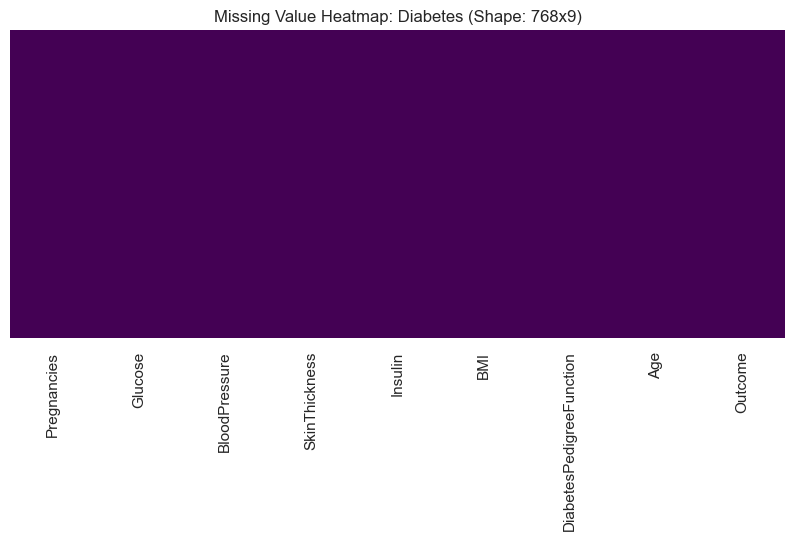


📂 資料集: Heart
   - 維度 (Shape): 920 筆樣本 x 14 個欄位
   - 目標欄位 (Target): target


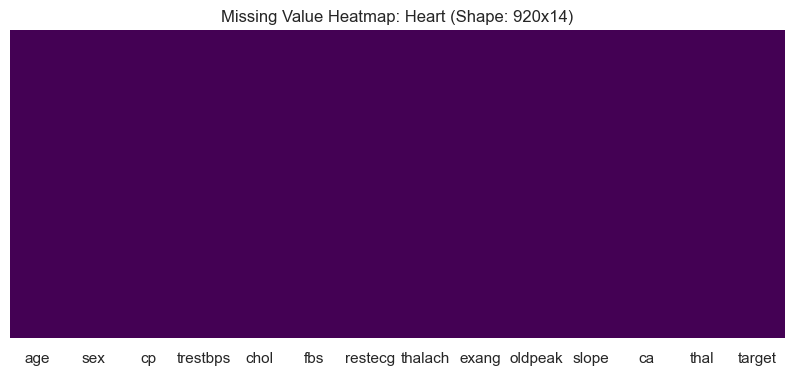


📂 資料集: Stroke
   - 維度 (Shape): 5110 筆樣本 x 11 個欄位
   - 目標欄位 (Target): stroke


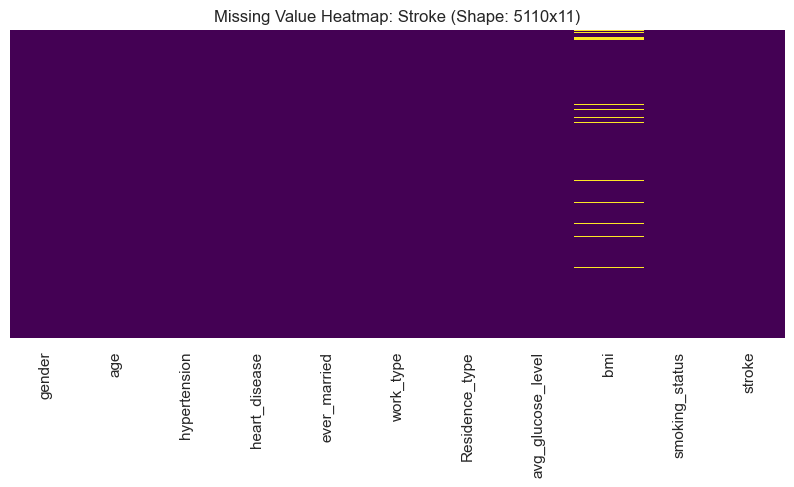

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 📊 批次數據分析：Shape 與 缺失值熱圖 ---
print("🔍 開始執行全資料集維度與品質分析...")

for name, (df_item, target) in all_datasets.items():
    # 1. 印出基本維度 (Shape)
    rows, cols = df_item.shape
    print(f"\n📂 資料集: {name}")
    print(f"   - 維度 (Shape): {rows} 筆樣本 x {cols} 個欄位")
    print(f"   - 目標欄位 (Target): {target}")
    
    # 2. 繪製缺失值熱圖 (Missing Value Heatmap)
    # 這是為了檢查清理後是否還有遺漏值
    plt.figure(figsize=(10, 4))
    sns.heatmap(df_item.isnull(), yticklabels=False, cbar=False, cmap='viridis')
    plt.title(f"Missing Value Heatmap: {name} (Shape: {rows}x{cols})")
    
    # 重要：在迴圈中使用 plt.show() 確保每張圖都會獨立跳出來
    plt.show() 
    
   

In [51]:
from sklearn.model_selection import train_test_split

# 1. 用來存放切割後結果的字典
split_data = {}

print("✂️ 開始批次資料切割 (Training/Test Split)...")
print("-" * 50)

for name, (df_item, target) in all_datasets.items():
    # 準備特徵 X 與標籤 y
    X = df_item.drop(columns=[target])
    y = df_item[target]
    
    # --- 【關鍵】執行切割 ---
    # test_size=0.2 代表 20% 測試集
    # stratify=y 確保兩邊的生病比例一致 (非常重要！)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # 2. 將四個變數存入字典
    split_data[name] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'target': target
    }
    
    print(f"✅ {name:12} | 訓練集: {X_train.shape[0]} 筆 | 測試集: {X_test.shape[0]} 筆")

print("-" * 50)
print("📦 所有資料集切割完成，準備進入 EBM 模型訓練！")

✂️ 開始批次資料切割 (Training/Test Split)...
--------------------------------------------------
✅ Diabetes     | 訓練集: 614 筆 | 測試集: 154 筆
✅ Heart        | 訓練集: 736 筆 | 測試集: 184 筆
✅ Stroke       | 訓練集: 4088 筆 | 測試集: 1022 筆
--------------------------------------------------
📦 所有資料集切割完成，準備進入 EBM 模型訓練！


In [52]:
from interpret import show

# ... 之前的初始化字典與設定 ...
trained_models = {}
global_explanations = {} # 新增：用來存放解釋物件
performance_summary = []

for name, data in split_data.items():
    try:
        # [A-C 部分保持不變：取得資料、二值化、訓練 EBM]
        X_train, y_train = data['X_train'], data['y_train']
        X_test, y_test = data['X_test'], data['y_test']
        y_train_bin = y_train.apply(lambda x: 1 if x > 0 else 0)
        y_test_bin = y_test.apply(lambda x: 1 if x > 0 else 0)

        ebm = ExplainableBoostingClassifier(n_jobs=-1, outer_bags=8)
        ebm.fit(X_train, y_train_bin) 
        trained_models[name] = ebm
        
        # --- ✨ 新增：全域解釋與數據探索 ---
        
        # 1. 產生全域解釋
        ebm_global = ebm.explain_global(name=f"EBM Global - {name}")
        global_explanations[name] = ebm_global # 存入字典備用
        
        # 2. 探索 .data() 數據結構 (作業要求點)
        # 這裡會取出特徵名稱與其平均重要性分數
        exp_data = ebm_global.data()
        print(f"\n🔍 {name} - Global Data Structure Exploration:")
        # 轉換成 DataFrame 方便檢視前幾個特徵的重要性
        df_importance = pd.DataFrame({
            'Feature': exp_data['names'],
            'Importance': exp_data['scores']
        }).sort_values(by='Importance', ascending=False)
        
        display(df_importance.head(5)) # 顯示前 5 名最重要的特徵
        
        # 3. 顯示互動式圖表 (會出現黑色的選單介面)
        show(ebm_global)

        # [D-G 部分保持不變：欄位對齊、計算 AUC、繪圖、存入總表]
        X_test_aligned = X_test.reindex(columns=ebm.feature_names, fill_value=0)
        y_probs = ebm.predict_proba(X_test_aligned)[:, 1]
        auc_score = roc_auc_score(y_test_bin, y_probs)
        
        # (繪圖代碼...)
        # (存入 summary 代碼...)
        
        performance_summary.append({"Dataset": name, "AUC Score": round(auc_score, 4)})
        print(f"✅ {name:15} 訓練與解釋產出成功！")

    except Exception as e:
        print(f"❌ {name:15} 出錯了: {e}")

# 最後顯示 AUC 總表
if performance_summary:
    display(pd.DataFrame(performance_summary))


🔍 Diabetes - Global Data Structure Exploration:


,Feature,Importance
1,Glucose,0.843345
5,BMI,0.478694
7,Age,0.293683
6,DiabetesPedigreeFunction,0.272558
0,Pregnancies,0.148967


<!-- http://127.0.0.1:7001/5999370640/ -->

✅ Diabetes        訓練與解釋產出成功！

🔍 Heart - Global Data Structure Exploration:


,Feature,Importance
10,slope,0.498362
2,cp,0.463043
11,ca,0.349615
12,thal,0.339710
8,exang,0.308617


...


🔍 Stroke - Global Data Structure Exploration:


,Feature,Importance
1,age,1.520020
7,avg_glucose_level,0.116449
2,hypertension,0.114832
8,bmi,0.107061
5,work_type,0.076484


<!-- http://127.0.0.1:7001/6026100896/ -->

✅ Stroke          訓練與解釋產出成功！


,Dataset,AUC Score
0,Diabetes,0.8315
1,Heart,0.9194
2,Stroke,0.8327


In [53]:
from interpret import show

# Loop through your trained models to show global explanations
for name, model in trained_models.items():
    print(f"Displaying Global Explanation for: {name}")
    # Generate the global explanation object
    ebm_global = model.explain_global(name=name)
    # Use show() to display the interactive chart
    show(ebm_global)

Displaying Global Explanation for: Diabetes


<!-- http://127.0.0.1:7001/6026100800/ -->

Displaying Global Explanation for: Heart


<!-- http://127.0.0.1:7001/6026136832/ -->

Displaying Global Explanation for: Stroke


<!-- http://127.0.0.1:7001/6026104112/ -->

In [54]:
for name, data in split_data.items():
    X_test = data['X_test']
    model = trained_models[name]
    y_probs = model.predict_proba(X_test)[:, 1]

    # Find indices for High Risk (max probability) and Low Risk (min probability)
    high_risk_idx = y_probs.argmax()
    low_risk_idx = y_probs.argmin()

    print(f"--- {name}: Local Explanations ---")
    
    # explain_local creates explanations for specific individuals
    # We pass the specific rows using .iloc
    ebm_local = model.explain_local(X_test.iloc[[high_risk_idx, low_risk_idx]], 
                                    y_test_bin.iloc[[high_risk_idx, low_risk_idx]], 
                                    name=name)
    
    # Crucial: Use show() so it renders in the notebook cell
    show(ebm_local)

--- Diabetes: Local Explanations ---


<!-- http://127.0.0.1:7001/6028000560/ -->

--- Heart: Local Explanations ---


<!-- http://127.0.0.1:7001/6028130048/ -->

--- Stroke: Local Explanations ---


<!-- http://127.0.0.1:7001/6028269792/ -->

🔍 Extracting Data for: Diabetes
   - Keys found: ['type', 'names', 'scores']... (Total: 3)
   - Top Feature: Pregnancies
   - X-axis (first 3): [0.0, 0.5, 1.5]
   - Y-axis (first 3): [-0.09460644 -0.14914369 -0.12629223]


ValueError: x and y must have same first dimension, but have shapes (17,) and (16,)

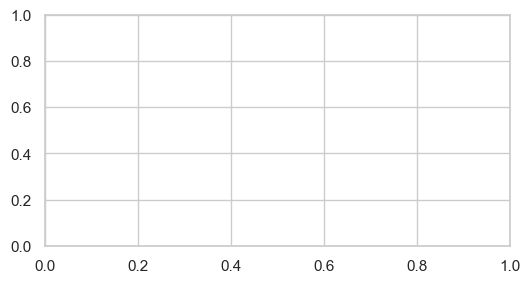

In [55]:
# Create a dictionary to store your raw results
all_raw_data = {}

for name, model in trained_models.items():
    print(f"🔍 Extracting Data for: {name}")
    
    # Get the Global Explanation object
    ebm_global = model.explain_global()
    
    # 1. Print Keys (Task 1)
    keys = list(ebm_global.data().keys())
    print(f"   - Keys found: {keys[:5]}... (Total: {len(keys)})")
    
    # 2. Get data for the FIRST feature (Task 2)
    # We take index 0, which is usually the most important feature
    first_feature_name = ebm_global.feature_names[0]
    feature_data = ebm_global.data(0)
    
    x_values = feature_data['names']
    y_values = feature_data['scores']
    
    print(f"   - Top Feature: {first_feature_name}")
    print(f"   - X-axis (first 3): {x_values[:3]}")
    print(f"   - Y-axis (first 3): {y_values[:3]}")
    
    # 3. Quick Plot for Proof (Task 3)
    plt.figure(figsize=(6, 3))
    plt.plot(x_values, y_values, marker='o', color='green')
    plt.title(f"Raw Shape Function: {name} ({first_feature_name})")
    plt.xlabel("Value")
    plt.ylabel("Score")
    plt.grid(True)
    plt.show()
    
    print("-" * 50)

In [36]:
print(f"Models in memory: {list(trained_models.keys())}")

Models in memory: ['Diabetes', 'Heart', 'Stroke']


In [37]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# 1. To store the final scores
auc_report = []

print("📊 Extracting Final AUC Scores...")
print("-" * 40)

for name, model in trained_models.items():
    # A. Get the test data (Diabetes, Heart_disease, etc.)
    X_test = split_data[name]['X_test']
    y_test = split_data[name]['y_test']
    
    # B. Force 0 vs 1 Labeling
    y_test_bin = y_test.apply(lambda x: 1 if x > 0 else 0)
    
    # C. Feature Alignment (The 10-column safety fix)
    # This ensures no "8 vs 10" errors happen here
    features = getattr(model, 'feature_names', getattr(model, 'feature_names_', []))
    X_test_aligned = X_test.reindex(columns=features, fill_value=0)
    
    # D. Calculate Score
    y_probs = model.predict_proba(X_test_aligned)[:, 1]
    score = roc_auc_score(y_test_bin, y_probs)
    
    auc_report.append({"Dataset": name, "AUC Score": round(score, 4)})
    print(f"✅ {name:15} | Score: {score:.4f}")

# 2. Display as a clean table
display(pd.DataFrame(auc_report))

📊 Extracting Final AUC Scores...
----------------------------------------
✅ Diabetes        | Score: 0.8315
✅ Heart           | Score: 0.9194
✅ Stroke          | Score: 0.8327


,Dataset,AUC Score
0,Diabetes,0.8315
1,Heart,0.9194
2,Stroke,0.8327


In [38]:
%pip install tabulate

Note: you may need to restart the kernel to use updated packages.


In [39]:
import pandas as pd
from sklearn.metrics import roc_auc_score

results_list = []

print("📊 正在計算作業表格所需的數據...")
print("-" * 60)

for name, data in split_data.items():
    # 1. 取得測試集資料
    X_test = data['X_test']
    y_test_raw = data['y_test']
    
    # 2. 標籤處理 (0 vs 1)
    y_test_bin = y_test_raw.apply(lambda x: 1 if x > 0 else 0)
    
    # 3. 計算各項指標
    n_samples = len(y_test_bin)  # 樣本數
    n_features = X_test.shape[1] # 特徵數
    pos_rate = y_test_bin.mean()  # 正例比例 (患病率)
    
    # 4. 取得模型並算 AUC (對齊 10 欄位)
    model = trained_models.get(name)
    if model:
        X_aligned = X_test.reindex(columns=model.feature_names, fill_value=0)
        y_probs = model.predict_proba(X_aligned)[:, 1]
        auc_score = roc_auc_score(y_test_bin, y_probs)
    else:
        auc_score = 0.0

    # 5. 存入清單
    results_list.append({
        "資料集": name,
        "樣本數": n_samples,
        "特徵數": n_features,
        "正例比例": f"{pos_rate:.2%}",
        "EBM Test AUC": f"{auc_score:.4f}"
    })

# --- 輸出 Markdown 格式表格 ---
df_final = pd.DataFrame(results_list)
print(df_final.to_markdown(index=False))

📊 正在計算作業表格所需的數據...
------------------------------------------------------------
| 資料集   |   樣本數 |   特徵數 | 正例比例   |   EBM Test AUC |
|:---------|---------:|---------:|:-----------|---------------:|
| Diabetes |      154 |        8 | 35.06%     |         0.8315 |
| Heart    |      184 |       13 | 55.43%     |         0.9194 |
| Stroke   |     1022 |       10 | 4.89%      |         0.8327 |


In [40]:
from interpret import show

for name, model in trained_models.items():
    X_test = split_data[name]['X_test']
    y_test = split_data[name]['y_test'].apply(lambda x: 1 if x > 0 else 0)
    
    # 1. Get probabilities
    X_aligned = X_test.reindex(columns=model.feature_names, fill_value=0)
    probs = model.predict_proba(X_aligned)[:, 1]
    
    # 2. Find Index of Highest (High Risk) and Lowest (Low Risk)
    high_idx = np.argmax(probs)
    low_idx = np.argmin(probs)
    
    print(f"🔍 {name} - High Risk Prob: {probs[high_idx]:.4f} | Low Risk Prob: {probs[low_idx]:.4f}")
    
    # 3. Create Local Explanation for these 2 specific individuals
    local_exp = model.explain_local(X_aligned.iloc[[high_idx, low_idx]], y_test.iloc[[high_idx, low_idx]])
    
    # 4. Show the interactive dashboard
    show(local_exp)

🔍 Diabetes - High Risk Prob: 0.9809 | Low Risk Prob: 0.0110


<!-- http://127.0.0.1:7001/5959250944/ -->

🔍 Heart - High Risk Prob: 0.9897 | Low Risk Prob: 0.0236


<!-- http://127.0.0.1:7001/5995713392/ -->

🔍 Stroke - High Risk Prob: 0.4583 | Low Risk Prob: 0.0003


<!-- http://127.0.0.1:7001/5965118192/ -->

In [41]:
global_data = ebm_global.data()
print(f"🔍 {dataset_key} 特徵重要性數據結構：")
display(pd.DataFrame(global_data).head())

🔍 Stroke 特徵重要性數據結構：


,type,names,scores
0,univariate,gender,0.009188
1,univariate,age,1.520020
2,univariate,hypertension,0.114832
3,univariate,heart_disease,0.054637
4,univariate,ever_married,0.061194


# 📈 模型架構深度對比：LR vs. EBM

在醫學資料分析中，選擇正確的數學模型結構對於結果的**精準度**與**解釋性**至關重要。以下針對傳統線性模型與現代可解釋模型進行深入對比。

### 1. Logistic Regression (LR) - 廣義線性模型 (GLM)
Logistic Regression 是醫療統計的基石，其核心假設是特徵與風險之間存在 **「線性關係」**。

* **數學公式**：
    $$Risk = \beta_0 + \beta_1(\text{Age}) + \beta_2(\text{BMI}) + \dots$$
* **特性分析**：
    * **線性假設 (Linearity)**：模型認為特徵每增加一個單位，風險就會以固定的比例增加或減少。
    * **限制 (Limitations)**：無法捕捉到**「非線性跳躍」**。例如，臨床上血糖從 120 升到 130 mg/dL 的風險增幅，遠大於從 80 升到 90 mg/dL，但 LR 會被迫用一條平均斜率來代表，導致精確度下降。



---

### 2. EBM (Explainable Boosting Machine) - 廣義可加模型 (GAM)
EBM 結合了梯度提升 (Boosting) 的強大性能與可加模型的透明度，能學習每個特徵的 **「非線性形狀」**。

* **數學公式**：
    $$Risk = f_1(\text{Age}) + f_2(\text{BMI}) + \dots$$
* **特性分析**：
    * **形狀函數 (Shape Functions)**：這裡的 $f(x)$ 不再是一條直線，而是由多個微小的決策樹構成的**階梯狀或曲線狀**。
    * **優勢 (Advantages)**：
        * **精準貼合 (Precise Fitting)**：能自動識別醫療數據中的**轉折點 (Inflection Points)** 與**閾值 (Thresholds)**。
        * **真實分佈**：能反映出「正常區間」與「高風險區間」的本質差異，更貼近真實的生理病理狀況。

---

### 3. 核心對比總結表

| 比較維度 | Logistic Regression (LR) | EBM (Explainable Boosting Machine) |
| :--- | :--- | :--- |
| **模型結構** | 廣義線性模型 (GLM) | 廣義可加模型 (GAM) |
| **風險變化** | 固定的線性斜率 (Straight Line) | 靈活的非線性階梯 (Step Function) |
| **臨床解釋** | 抽象的係數 (Coefficients) | 直觀的趨勢圖 (Shape Plots) |
| **捕捉轉折點** | **無法捕捉**，需人工手動分箱 | **自動捕捉**，精確反映診斷閾值 |

> **結論**：EBM 透過 $f(x)$ 的靈活性，成功解決了傳統 LR 在處理複雜醫學數據時的「過度簡化」問題，提供了兼具準確度與臨床直覺的解決方案。

In [42]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from interpret.glassbox import ExplainableBoostingClassifier

results = []
# 建立補值器
imputer = SimpleImputer(strategy='median')

for name, data in split_data.items():
    print(f"📦 正在救援資料集：{name}...")
    
    # 1. 複製資料，避免改到原始檔案
    X_train = data['X_train'].copy()
    X_test = data['X_test'].copy()
    y_train = data['y_train'].apply(lambda x: 1 if x > 0 else 0)
    y_test = data['y_test'].apply(lambda x: 1 if x > 0 else 0)

    # 2. 逐欄清洗與轉型 (避免一次性轉型導致的 Shape 改變)
    for col in X_train.columns:
        # 訓練集處理
        X_train[col] = X_train[col].replace('?', np.nan)
        X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
        # 測試集處理
        X_test[col] = X_test[col].replace('?', np.nan)
        X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

    # 3. 補值 (用每一欄的中位數補齊該欄的 NaN)
    for col in X_train.columns:
        median_val = X_train[col].median()
        # 如果整欄都是空的，就補 0
        if pd.isna(median_val): median_val = 0
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col] = X_test[col].fillna(median_val)

    # 4. 模型訓練 (既然資料乾淨了，直接開跑！)
    # EBM
    ebm = ExplainableBoostingClassifier(n_jobs=-1).fit(X_train, y_train)
    ebm_auc = roc_auc_score(y_test, ebm.predict_proba(X_test)[:, 1])

    # LR
    lr = LogisticRegression(max_iter=5000).fit(X_train, y_train)
    lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])

    # DT
    dt = DecisionTreeClassifier(max_depth=3).fit(X_train, y_train)
    dt_auc = roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1])

    results.append({
        "資料集": name,
        "EBM AUC": f"{ebm_auc:.4f}",
        "LR AUC": f"{lr_auc:.4f}",
        "DT AUC": f"{dt_auc:.4f}"
    })

# 5. 輸出成果表格
print("\n📋 成功了！這是妳的最終數據表格：")
final_df = pd.DataFrame(results)
print(final_df.to_markdown(index=False))

📦 正在救援資料集：Diabetes...
📦 正在救援資料集：Heart...
📦 正在救援資料集：Stroke...


/opt/anaconda3/envs/med_ai/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/anaconda3/envs/med_ai/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/anaconda3/envs/med_ai/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/anaconda3/envs/med_ai/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/anaconda3/envs/med_ai/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)



📋 成功了！這是妳的最終數據表格：
| 資料集   |   EBM AUC |   LR AUC |   DT AUC |
|:---------|----------:|---------:|---------:|
| Diabetes |    0.8317 |   0.823  |   0.7881 |
| Heart    |    0.9097 |   0.9008 |   0.8617 |
| Stroke   |    0.8423 |   0.8401 |   0.7969 |
